# Career-ending injuries: a yes/no model

The severity model (`severity_models.ipynb`) predicts how many days an injury costs. This notebook models the most expensive outcome separately: **does the injury end the player's career?** For an insurer this is the claim that pays out the remaining contract, so it gets its own model instead of being one long tail of the days-missed distribution.

The code is in `career.py`. MySQL must be running, with the soccer data loaded, including appearances (`python build_db.py soccer data/football-datasets`).

## 1. Defining "career-ending"

No data source says "this injury ended his career", so the label is built from appearance records (`player_seasons`). An injury is **career-ending** when:
1. the player never made another recorded professional appearance in a season that started after the injury, **and**
2. he had not returned from the injury by the end of the season it happened in.

Other rules:
- **First such injury only:** only a player's first qualifying injury counts. His later injuries are dropped, because the career is already over.
- **Follow-up:** an injury is only labeled when **two complete seasons** of appearance data follow it, so a player still rehabbing isn't mistaken for a retirement. The 25/26 season is only partly downloaded, so this means injuries before July 2023.
- **Exclusions:** players who died are excluded, as are entries that aren't injuries (rest, fitness, suspension).

**"Professional" means a competition Transfermarkt records appearances for.** A player who drops to amateur football after the injury counts as career-ending, which matches what professional career insurance covers. Some of these players appear in their profile as currently at small amateur clubs.

**Predictors** are only things known on the day of the injury: body region, injury type, age, position, injury history, market value and recent minutes. How long the injury eventually lasted is **not** used, because it isn't known when the policy is priced or the injury happens.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import career
import severity as sev

pd.set_option("display.width", 160)
pd.set_option("display.max_rows", 80)

data = career.build_dataset()
train, test = career.split(data)      # by player
print(f"{len(data):,} injuries before {data.attrs['cutoff']:%Y-%m-%d}; "
      f"{data.career_ending.sum():,} career-ending ({data.career_ending.mean():.2%})")
print(f"train {len(train):,} / test {len(test):,}")

120,682 injuries before 2023-07-01; 504 career-ending (0.42%)
train 96,833 / test 23,849


### Checking the label

If the definition works, career-ending injuries should be dominated by serious diagnoses, and those players' profiles should mostly say *Retired* or *Without Club*, or show a small amateur club. Their eventual time out should also be long.

In [2]:
ended = data[data.career_ending == 1]
print("Most common descriptions:")
print(ended.injury_desc.value_counts().head(12).to_string())
status = np.select([ended.current_club.isin(["Retired", "Without Club", "Career break"]),
                    ended.current_club.isin(["Unknown", "---"]) | ended.current_club.isna()],
                   ["Retired / without club", "Unknown"], "At a club (mostly amateur)")
print("\nProfile status today:")
print(pd.Series(status).value_counts(normalize=True).round(3).to_string())
print(f"\nMedian days out: career-ending {ended.days_missed.median():.0f} vs. all others {data[data.career_ending == 0].days_missed.median():.0f}")

Most common descriptions:
injury_desc
Cruciate ligament tear       115
unknown injury                49
Knee injury                   43
Knee surgery                  21
Cartilage damage              18
Achilles tendon rupture       13
Knee problems                 13
heart problems                11
Cruciate ligament injury      11
Cruciate ligament surgery      9
Shoulder injury                9
Achilles tendon surgery        8

Profile status today:
Retired / without club        0.843
At a club (mostly amateur)    0.143
Unknown                       0.014

Median days out: career-ending 349 vs. all others 22


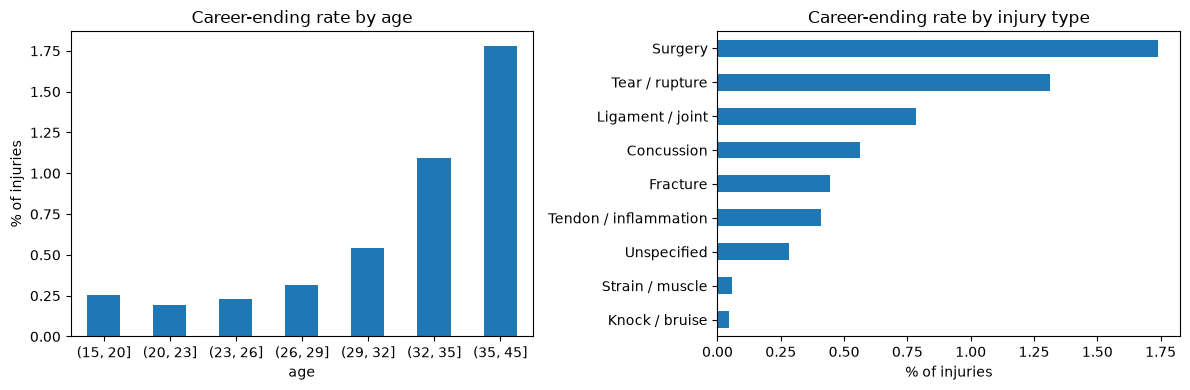

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
by_age = data.groupby(pd.cut(data.age, [15, 20, 23, 26, 29, 32, 35, 45]), observed=True).career_ending.mean() * 100
by_age.plot.bar(ax=ax[0], rot=0); ax[0].set(title="Career-ending rate by age", ylabel="% of injuries", xlabel="age")
by_type = data.groupby("nature", observed=True).career_ending.mean().sort_values() * 100
by_type.plot.barh(ax=ax[1]); ax[1].set(title="Career-ending rate by injury type", xlabel="% of injuries", ylabel="")
plt.tight_layout()

## 2. Models

| Model | |
|---|---|
| Base rate | Every injury gets the average rate; the floor to beat |
| **Logistic GLM, main effects** | Logistic regression: the binary counterpart of the gamma GLM, with odds ratios you can put in a rating table |
| Logistic GLM + interactions | The interactions chosen by forward selection on a validation split of the training data |
| Gradient boosting | Trees; a benchmark for missed non-linear effects |

Career-ending injuries are rare (about 0.4%), so any body region or injury type with fewer than 20 career-ending injuries in the training data is merged into **Other**. Otherwise its coefficient can't be estimated. The same rare-group idea as the severity rating classes, but applied to the much smaller number of events here.

In [4]:
path, chosen = career.select_interactions(train)
path

,step,val_log_loss,improvement_vs_previous
0,main effects,0.019940,NaN
1,+ market value x injury type,0.019793,0.000147
2,+ minutes (12 months) x age,0.019763,0.000030


In [5]:
models = career.fit_all(train, career.default_models(chosen))

  fitting Base rate, no predictors ...


  fitting Logistic GLM, main effects ...


  fitting Logistic GLM + interactions ...


  fitting Gradient boosting ...


## 3. Held-out comparison

- **auc:** how well the model ranks career-ending injuries above the others. 0.5 is guessing, 1 is perfect.
- **avg_precision:** precision-recall area. Guessing scores the base rate (about 0.004), so compare against that.
- **log_loss / brier:** how good the probabilities themselves are; lower is better. These matter most for pricing.
- **mean_pred:** average predicted rate; should match the actual rate.
- **top10_capture:** share of all career-ending injuries that fall in the 10% of injuries the model rates riskiest.

In [6]:
career.compare(models, test)

,auc,avg_precision,log_loss,brier,mean_pred,top10_capture
model,,,,,,
"Base rate, no predictors",0.50000,0.00457,0.02921,0.00455,0.00408,0.00000
"Logistic GLM, main effects",0.86945,0.05685,0.02386,0.00446,0.00401,0.61468
Logistic GLM + interactions,0.86788,0.05573,0.02394,0.00446,0.00403,0.61468
Gradient boosting,0.86992,0.04461,0.02442,0.00449,0.00400,0.63303
(actual),NaN,NaN,NaN,NaN,0.00457,NaN


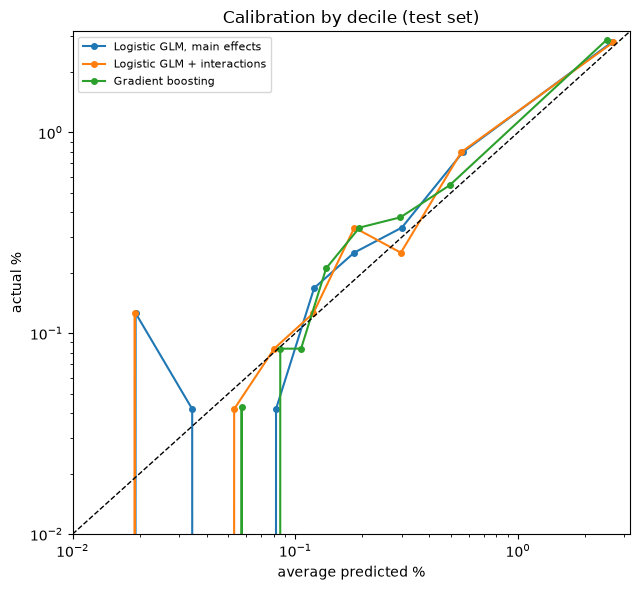

In [7]:
cal = career.calibration(models, test)
fig, ax = plt.subplots(figsize=(6.5, 6))
for name, g in cal.groupby("model", sort=False):
    ax.plot(g.pred * 100, g.actual * 100, "o-", ms=4, label=name)
lim = [0.01, max(cal.pred.max(), cal.actual.max()) * 110]
ax.plot(lim, lim, "k--", lw=1)
ax.set(xscale="log", yscale="log", xlim=lim, ylim=lim, xlabel="average predicted %", ylabel="actual %",
       title="Calibration by decile (test set)")
ax.legend(fontsize=8)
plt.tight_layout()

## 4. What raises the risk (logistic GLM odds ratios)

An odds ratio of 3 means three times the odds of the injury ending the career; at rates this low, that is roughly three times the probability. The baseline is a 26-year-old midfielder with an unspecified hamstring injury in 2015, typical market value (€500k) and average playing time.

In [8]:
career.odds_ratios(models["Logistic GLM, main effects"])

,odds_ratio,ci_low,ci_high,p_value
Intercept,0.0027,0.0008,0.0091,0.0000
region_g = Achilles,7.5924,2.5433,22.6655,0.0003
region_g = Knee,8.5250,3.0974,23.4636,0.0000
region_g = Other,1.3977,0.5079,3.8467,0.5168
region_g = Unknown,2.5730,0.9376,7.0606,0.0665
nature_g = Ligament / joint,1.4208,0.9336,2.1621,0.1011
nature_g = Other,0.8218,0.5652,1.1949,0.3041
nature_g = Surgery,3.0588,2.0398,4.5871,0.0000
nature_g = Tear / rupture,2.8082,2.1261,3.7091,0.0000
position_group = Attack,0.8320,0.6176,1.1208,0.2265


## Reading the results

These numbers come from the run saved here. The split uses a fixed seed (`seed=42`), so re-running gives the same results.

- **The label holds up.** Of the 504 career-ending injuries:
  - **Players:** 84% belong to players now listed as retired or without a club. Most of the rest are at amateur clubs.
  - **Diagnoses:** cruciate ligament tears lead the list, followed by other knee injuries and Achilles ruptures.
  - **Time out:** the median injury lasted 349 days, against 22 for other injuries.
- **The model ranks risk well.** The logistic GLM scores an AUC of about 0.87, and the 10% of injuries it rates riskiest contain 61% of all career-ending injuries. Its average precision (0.057) is about 12× the base rate.
- **Simple beats complex here.** The two interactions chosen on the validation split made the held-out results slightly *worse*, so they were fitting noise; there are only about 400 career-ending injuries to learn from. Gradient boosting ranks about as well (AUC 0.870) but its probabilities are worse (higher log loss, lower average precision). **Use the main-effects logistic GLM.**
- **Calibration:** in the top tenth of predicted risk, the predicted rate is about 2.5% and the actual rate about 2.8%. The lowest tenths have almost no career-ending injuries at all, which is why their points drop to zero on the log scale.
- **The diagnosis drives the risk:**
  - Knee injuries carry about 8.5× the odds of a hamstring injury, and Achilles injuries about 7.6×.
  - On top of the body region, surgery and tears/ruptures each about triple the odds.
- **The player matters too:**
  - **Age:** the odds rise about 24% per year at 26, slowing somewhat at older ages.
  - **Position:** defenders are about 1.4× midfielders.
  - **Playing time:** more minutes in the past year sharply lowers the risk (×0.61 per log unit).
  - **Market value:** a higher value lowers the risk, and players with no market value (lower leagues) have about 3.9× the odds. Dropping out of professional football is simply easier at that level.
  - **Year:** the upward trend (+6% per year) probably reflects better coverage of lower leagues over time rather than more careers ending.

**Using it with the severity model:** expected injury cost ≈ P(career-ending) × remaining contract value + (1 − P(career-ending)) × expected days missed × daily salary. The two models together cover both the common short injuries and the rare catastrophic ones.